In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [3]:
df =pd.read_csv('heart Dataset.csv')


In [5]:
df


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [44]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [45]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
df[df.duplicated()]


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
15,34,0,1,118,210,0,1,192,0,0.7,2,0,2,1
31,50,0,1,120,244,0,1,162,0,1.1,2,0,2,1
43,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
55,55,1,0,140,217,0,1,111,1,5.6,0,0,3,0
61,66,0,2,146,278,0,0,152,0,0.0,1,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [8]:
df.duplicated().sum() # Sum of duplicated values


723

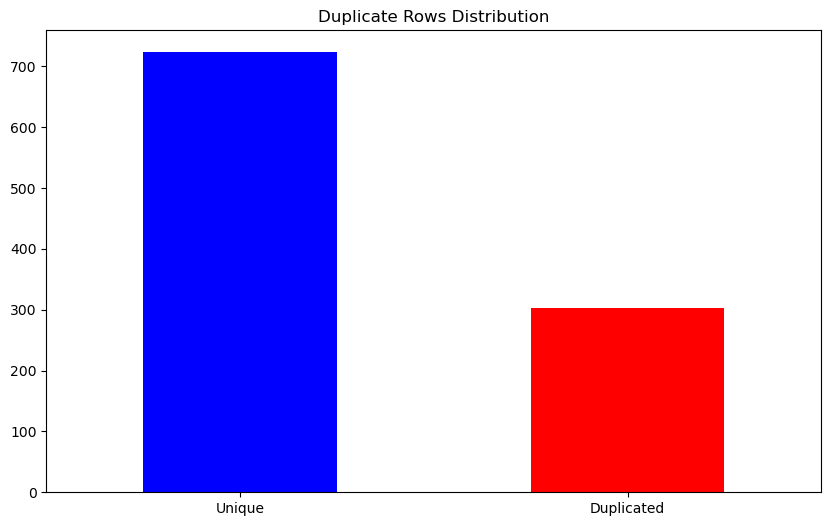

In [11]:
plt.figure(figsize=(10,6))
df.duplicated().value_counts().plot(kind='bar',
                                   color=['Blue', 'Red'],
                                   title='Duplicate Rows Distribution')
plt.xticks([0, 1], ['Unique', 'Duplicated'], rotation=0)
plt.show()

New shape: (302, 14)
Remaining duplicates: 0


([<matplotlib.axis.XTick at 0x23e39ce24d0>,
 [Text(0, 0, 'Unique'), Text(1, 0, 'Duplicated')])

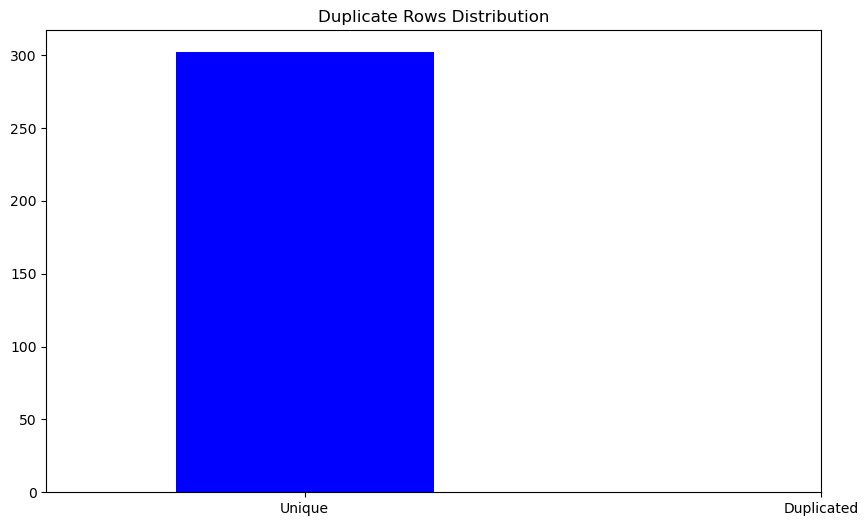

In [13]:
df_cleaned=df.drop_duplicates(keep='first') # Only keep first occurences, drop the rest
print(f"New shape: {df_cleaned.shape}")
print(f"Remaining duplicates: {df_cleaned.duplicated().sum()}")
plt.figure(figsize=(10,6))
df_cleaned.duplicated().value_counts().plot(kind='bar',
                                   color=['blue', 'salmon'],
                                   title='Duplicate Rows Distribution')
plt.xticks([0, 1], ['Unique', 'Duplicated'], rotation=0) # Visualize the dataset after handling the duplicates
     

1    526
0    499
Name: target, dtype: int64


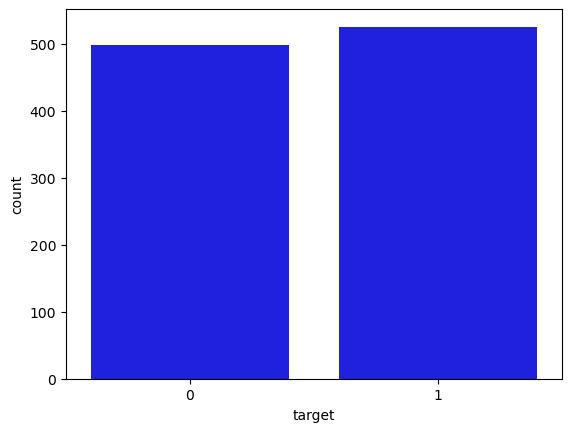

In [14]:
x=df.target.value_counts() # Visualize the count of target- 0 represents no disease, 1 represents disease
print(x)
p=sns.countplot(x=df.target, color='blue')
plt.show()

In [15]:
##Seperate X and y for training.


In [16]:
X=df.drop('target', axis=1)
y=df['target']

In [17]:
##Split the dataset for training and testing.


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=46)


In [19]:
dt_clf = DecisionTreeClassifier(ccp_alpha=0.0, criterion='gini', max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2)

dt_clf.fit(X_train, y_train)

DecisionTreeClassifier()

In [21]:
train_acc = accuracy_score(y_train, dt_clf.predict(X_train))
test_acc = accuracy_score(y_test, dt_clf.predict(X_test))

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 1.0
Test Accuracy: 1.0


In [25]:
##Use cross-validation to understand whether the model is overfitting.

In [24]:
cv_scores = cross_val_score(dt_clf, X, y, cv=5) # cv=5 means we're splitting the data into 5 parts and the model will be tested and trained 5 times each time using a diff. fold for testing
print("Cross-Validation Accuracy: %.3f ± %.3f" % (cv_scores.mean(), cv_scores.std()))


Cross-Validation Accuracy: 0.996 ± 0.008


Text(0.5, 1.0, 'Learning Curve')

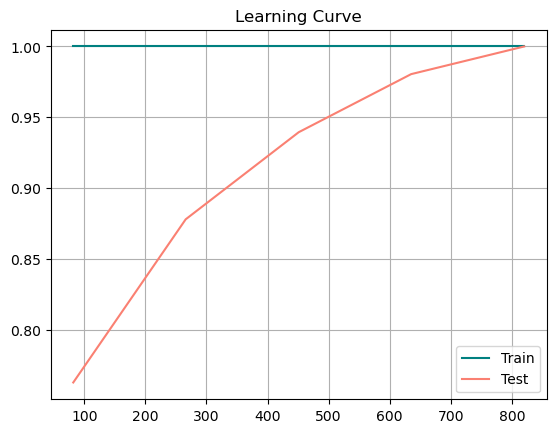

In [26]:
train_sizes, train_scores, test_scores = learning_curve(dt_clf, X, y, cv=5)

plt.plot(train_sizes, train_scores.mean(axis=1), label='Train', color='teal')
plt.plot(train_sizes, test_scores.mean(axis=1), label='Test', color='salmon')
plt.legend(); plt.grid()
plt.title("Learning Curve")


In [27]:
## Determine the optimal tree depth


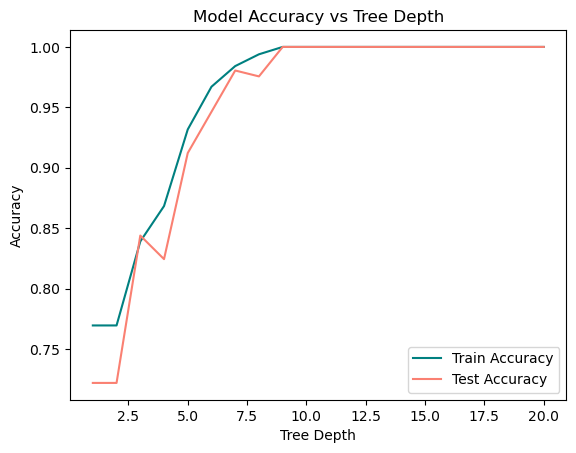

In [28]:
depths = range(1, 21)
train_acc, test_acc = [], [] # Initialzes 2 empty list to store accuracy scores for respective sets

for d in depths:
    model = DecisionTreeClassifier(max_depth=d).fit(X_train, y_train)
    train_acc.append(model.score(X_train, y_train))
    test_acc.append(model.score(X_test, y_test))

plt.plot(depths, train_acc, label='Train Accuracy', color='teal')
plt.plot(depths, test_acc, label='Test Accuracy', color='salmon')
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Model Accuracy vs Tree Depth")
plt.legend()

In [29]:
print("Tree Depth:", dt_clf.get_depth())
print("Number of Leaves:", dt_clf.get_n_leaves())

Tree Depth: 9
Number of Leaves: 48


In [30]:
##Use randomforestclassifier to compare accuracy(usually rfc yields a higher accuracy due to ensemble averaging).

In [31]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

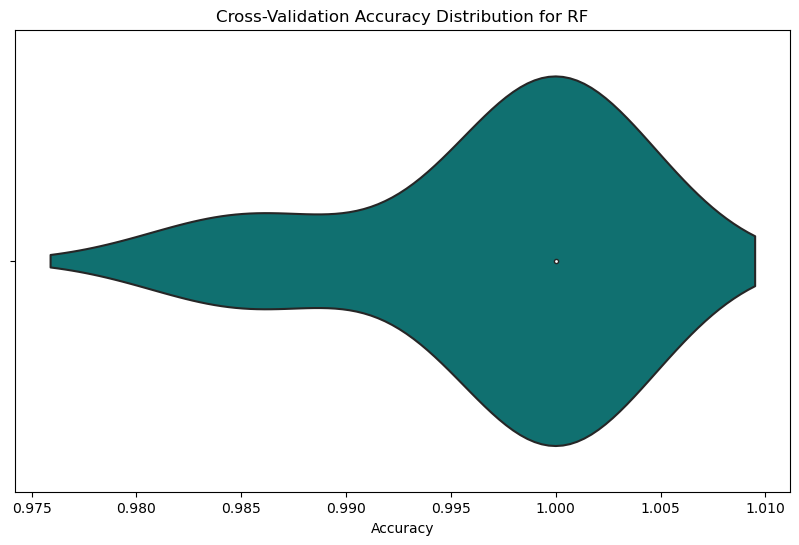

Cross-Validation Accuracy for: 1.00 ± 0.01


In [32]:
scores = cross_val_score(rf_clf, X, y, cv=5)
plt.figure(figsize=(10, 6))
sns.violinplot(x=scores, color='teal')
plt.title('Cross-Validation Accuracy Distribution for RF')
plt.xlabel('Accuracy')
plt.show()

print("Cross-Validation Accuracy for: {:.2f} ± {:.2f}".format(scores.mean(), scores.std()))

In [33]:
##Explore key features.


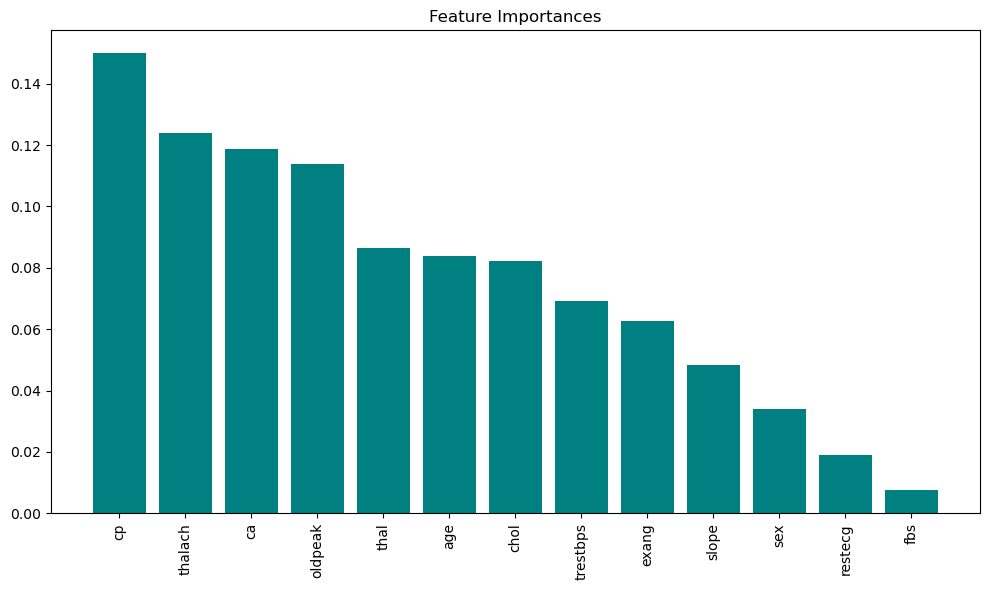

In [34]:
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align='center', color='teal')
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()


In [35]:
##Compare Decision tree classifier and Random forest classifier

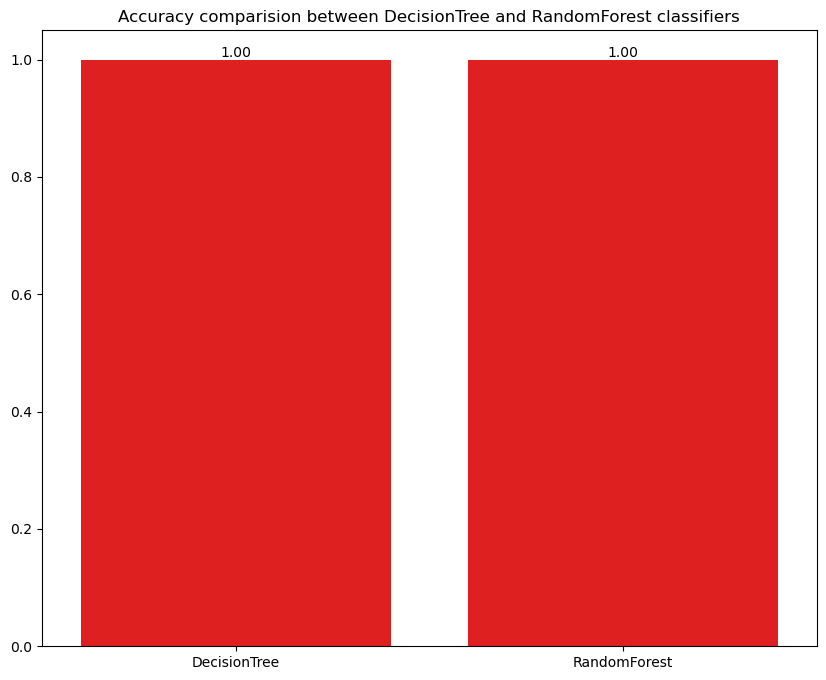

In [37]:
plt.figure(figsize=(10,8))
plt.title("Accuracy comparision between DecisionTree and RandomForest classifiers")
dt_acc = accuracy_score(y_test, dt_clf.predict(X_test))
rf_acc = accuracy_score(y_test, rf_clf.predict(X_test))
ax=sns.barplot(x=['DecisionTree', 'RandomForest'], y=[dt_acc, rf_acc], color='Red')
ax.bar_label(ax.containers[0], fmt='%.2f', label_type='edge')
plt.show()

In [38]:
##Plot a correlation matrix to understand relationship among features.

Text(0.5, 1.0, 'Feature Correlation Heatmap')

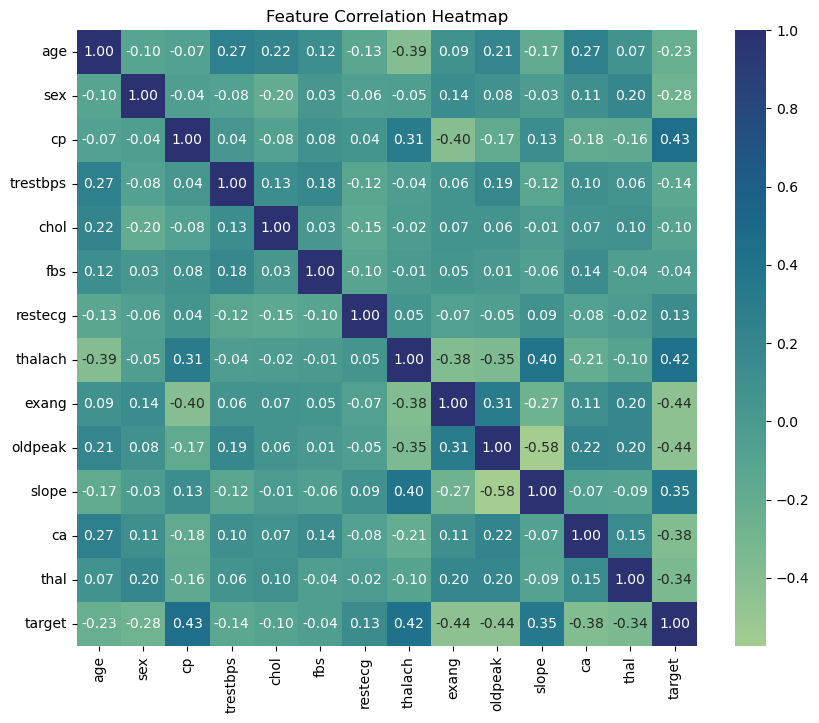

In [39]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='crest', fmt='.2f')
plt.title("Feature Correlation Heatmap")


In [40]:
##Plot a confusion matrix to be more confident that the model isn't overfitting.

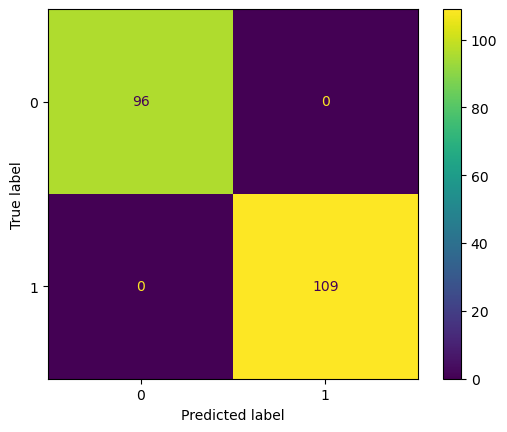

In [41]:
y_pred = dt_clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()


In [42]:
##Calculate precision, recall, F1-score to validate model's robustness.


In [43]:
y_pred = dt_clf.predict(X_test)
y_pred_rf = rf_clf.predict(X_test)

print("Decision Tree:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))
print("\nRandom Forest:")
print(classification_report(y_test, y_pred_rf, target_names=['No Disease', 'Disease']))

Decision Tree:
              precision    recall  f1-score   support

  No Disease       1.00      1.00      1.00        96
     Disease       1.00      1.00      1.00       109

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205


Random Forest:
              precision    recall  f1-score   support

  No Disease       1.00      1.00      1.00        96
     Disease       1.00      1.00      1.00       109

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205

